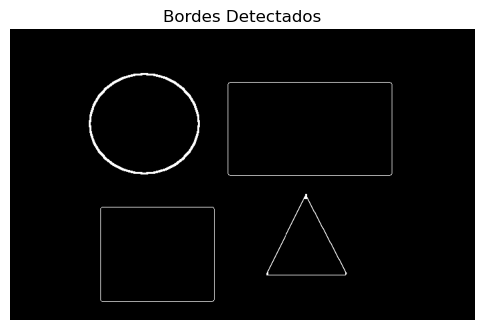

Contornos encontrados: 4

Forma: Cuadrado
Area: 25685.0
Vertices: 4
Momentos de Hu:
Hu[1] = 0.77079
Hu[2] = 3.00851
Hu[3] = 9.13639
Hu[4] = 10.14348
Hu[5] = -21.77328
Hu[6] = 11.80000
Hu[7] = 19.78344

Forma: Triangulo
Area: 7841.0
Vertices: 3
Momentos de Hu:
Hu[1] = 0.71179
Hu[2] = 3.17595
Hu[3] = 2.33448
Hu[4] = 4.60979
Hu[5] = 8.08825
Hu[6] = 6.20686
Hu[7] = -8.85297

Circulos encontrados: 2


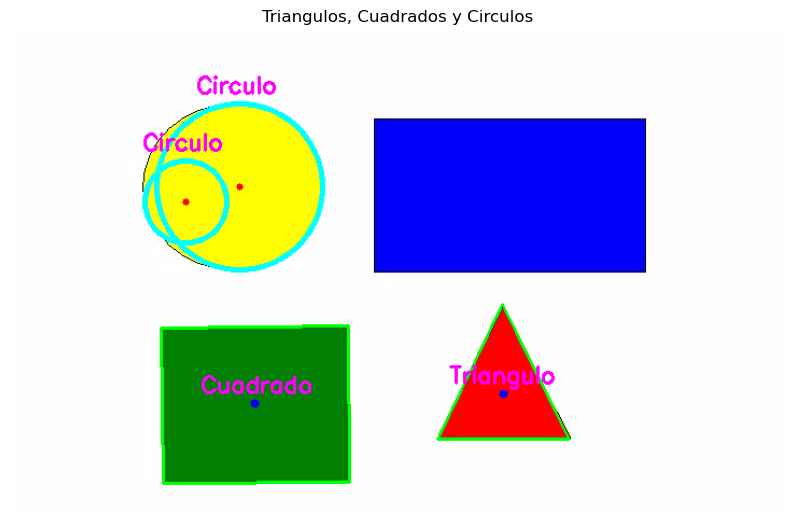

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("figuras.png")

if imagen is None:
    raise Exception("No se pudo cargar la imagen")

resultado = imagen.copy()

gris = cv2.cvtColor(
    imagen,
    cv2.COLOR_BGR2GRAY
)

blur = cv2.GaussianBlur(
    gris,
    (5, 5),
    0
)

bordes = cv2.Canny(
    blur,
    50,
    150
)

kernel = np.ones((3, 3), np.uint8)

bordes = cv2.morphologyEx(
    bordes,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.figure(figsize=(6,6))
plt.imshow(bordes, cmap="gray")
plt.title("Bordes Detectados")
plt.axis("off")
plt.show()

contornos, _ = cv2.findContours(
    bordes,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contornos encontrados:", len(contornos))

for i, contorno in enumerate(contornos):

    area = cv2.contourArea(contorno)

    if area < 100:
        continue

    M = cv2.moments(contorno)

    if M["m00"] == 0:
        continue

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    hu = cv2.HuMoments(M)

    perimetro = cv2.arcLength(
        contorno,
        True
    )

    aproximacion = cv2.approxPolyDP(
        contorno,
        0.02 * perimetro,
        True
    )

    vertices = len(aproximacion)

    forma = None

    if vertices == 3:
        forma = "Triangulo"

    elif vertices == 4:

        x, y, w, h = cv2.boundingRect(
            aproximacion
        )

        relacion = w / float(h)

        if 0.8 <= relacion <= 1.2:
            forma = "Cuadrado"

    if forma is None:
        continue


    cv2.drawContours(
        resultado,
        [aproximacion],
        -1,
        (0,255,0),
        2
    )

    cv2.circle(
        resultado,
        (cx, cy),
        4,
        (255,0,0),
        -1
    )

    cv2.putText(
        resultado,
        forma,
        (cx - 50, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,0,255),
        2
    )


    print("\n====================")
    print("Forma:", forma)
    print("Area:", area)
    print("Vertices:", vertices)

    print("Momentos de Hu:")

    for j in range(7):

        valor = hu[j][0]

        if valor != 0:
            valor = -np.sign(valor) * np.log10(abs(valor))

        print(f"Hu[{j+1}] = {valor:.5f}")


circulos = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=25,
    minRadius=10,
    maxRadius=200
)

if circulos is not None:

    circulos = np.round(
        circulos[0, :]
    ).astype("int")

    print("\nCirculos encontrados:", len(circulos))

    for (x, y, r) in circulos:

        cv2.circle(
            resultado,
            (x, y),
            r,
            (255, 255, 0),
            3
        )

        cv2.circle(
            resultado,
            (x, y),
            3,
            (0, 0, 255),
            -1
        )

        cv2.putText(
            resultado,
            "Circulo",
            (x - 40, y - r - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,0,255),
            2
        )


resultado_rgb = cv2.cvtColor(
    resultado,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10,8))
plt.imshow(resultado_rgb)
plt.title("Triangulos, Cuadrados y Circulos")
plt.axis("off")
plt.show()